# **Website Performance Analysis**

### Overview: 

In today’s digital-first world, a company’s website is one of its most valuable assets, often serving as both its storefront and its marketing hub. Every click, scroll, and interaction generates data that, when analyzed effectively, can reveal powerful insights into customer behavior, marketing performance, and overall user engagement. With over `1.1 billion websites` worldwide (as of 2025) and more than `60%` of internet traffic originating from mobile devices, the ability to interpret and act on website performance data has become a critical skill for data-driven businesses across every industry—from e‑commerce and finance to healthcare and logistics.

For this project, I worked as a real-world data analyst role where my task is to extract actionable business insights from raw website usage data. The dataset contains records covering user sessions, engagement time, traffic sources, and other key metrics. Just like in a professional environment, the goal is to translate these numbers into clear, data-backed recommendations that can help increase engagement, optimize marketing spend, and ultimately boost company revenue.


### Objectives:


1. Identify patterns and trends in website sessions and user activity over time.

2. Determine which marketing channels drive the highest number of users to the site.

3. Find the channels with the highest average engagement time.

4. Analyze how engagement rates vary across different traffic sources.

5. Discover which channels drive more engaged sessions compared to non-engaged ones.

6. Pinpoint the hours of the day with the highest website traffic to inform marketing campaign timing.

7. Explore the relationship between high traffic levels and high engagement.

Through Python-based **data cleaning, exploratory data analysis (EDA), and visualization**, I demonstrate how to turn raw website metrics into meaningful insights. By mastering this workflow, the resulting skill set can be applied to virtually any industry

---

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Reading the dataset into a pandas DataFrame

In [2]:
df = pd.read_csv('website_data.csv')
df.head()


,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


The column names are actually the first row of the dataset. We can use the iloc method to select the first row and assign it as the column names. Then, I remove the first row from the dataset.

In [4]:
df.columns = df.iloc[0]
df = df[1:]
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
5,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


Changing the column names of the data frame. Session primary channel group (Default channel group) -> Channel Group and Date + hour (YYYYMMDDHH) -> DateHour

In [18]:
columns = list(df.columns)
columns[0] = "Channel Group"
columns[1] = "DateHour"
df.columns = columns
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
5,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


Checking the data types of the columns using the info() method

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 1 to 3182
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Channel Group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   Sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


All the columns are in object type. I converted the DateHour column to datetime type and the other columns to int type.

In [20]:
df['DateHour'] = pd.to_datetime(df['DateHour'], format='%Y%m%d%H')
numeric_columns = df.columns.drop(['Channel Group', 'DateHour'])
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df["Hour"] = df['DateHour'].dt.hour
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
1,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
2,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
3,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
4,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
5,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 1 to 3182
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel Group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

Checking for any duplicate rows and removing them

In [23]:
print("Number of duplicate rows:", df.duplicated().sum().item(0))

Number of duplicate rows: 0


Checking for any missing values

In [26]:
print("Number of missing values:", df.isnull().sum().sum())

Number of missing values: 0


Calculating the basic statistics of the dataset

In [27]:
df.describe()

,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


---

### What are the patterns or trend between website sessions and the number of users over time?

Creating a line plot to check the trend of sessions and users over time

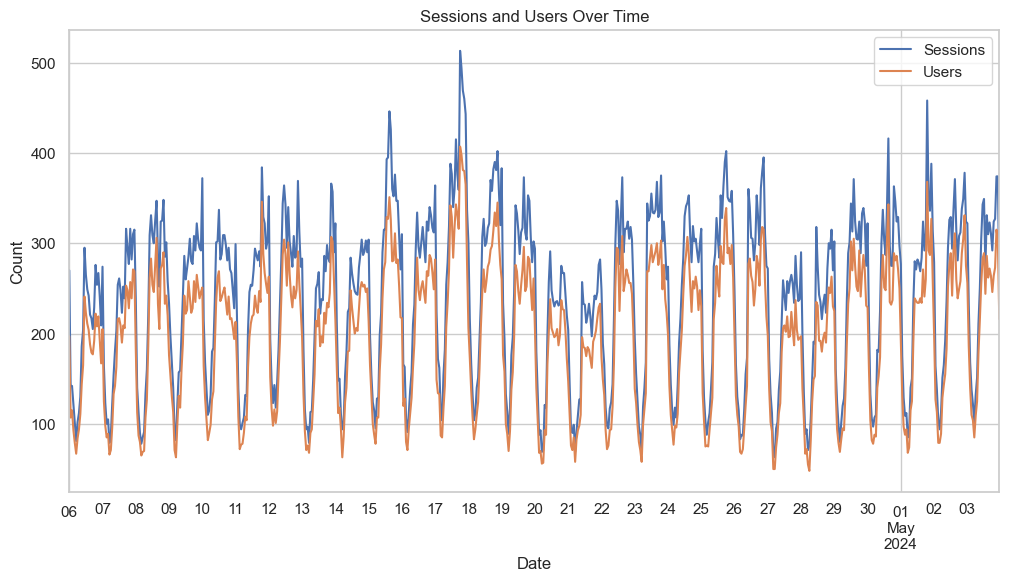

In [29]:
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
df.groupby("DateHour")[["Sessions", "Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions and Users Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

There is a clear trend of sessions and users over time. As the number of users increases, the number of sessions also increases which means the website is getting more traffic and engagement. Also, there is a peak during 17-18 April 2024.

---

### Which marketing channel brought the highest number of users to the website?


Creating a bar graph to show the number of users for each marketing channel

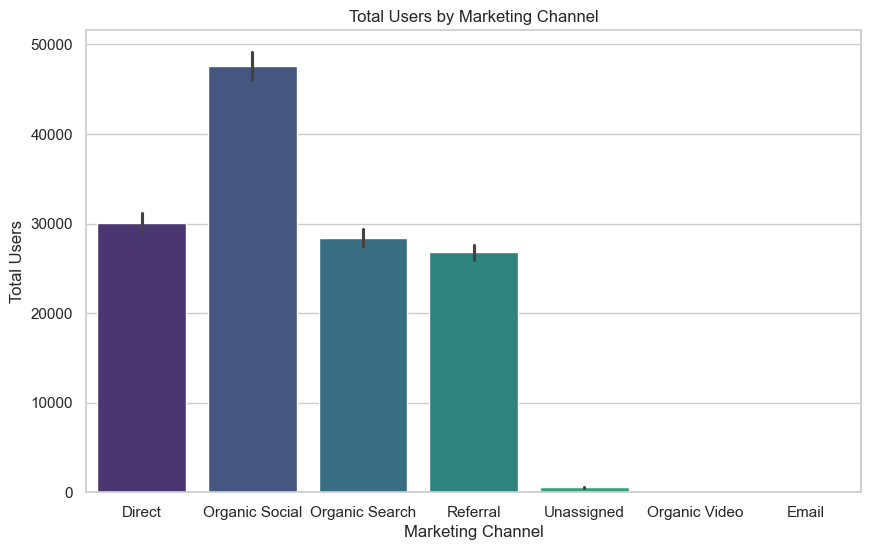

In [36]:
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize=(10, 6))
sns.barplot(x='Channel Group', y='Users', data= df, estimator=np.sum, palette='viridis')
plt.title('Total Users by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Total Users')
plt.show();

In [39]:
df.groupby('Channel Group')['Users'].sum().sort_values(ascending=False)

Channel Group
Organic Social    47572
Direct            30042
Organic Search    28387
Referral          26774
Unassigned          540
Organic Video       123
Email                 2
Name: Users, dtype: int64

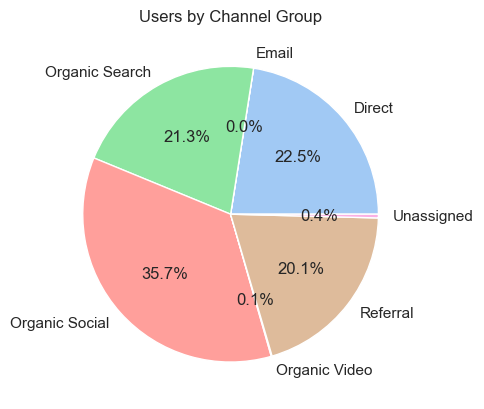

In [49]:
values = df.groupby('Channel Group')['Users'].sum().values
labels = df.groupby('Channel Group')['Users'].sum().index
sns.set_palette("pastel")
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Users by Channel Group')
plt.show();


As we can see through the graph, the most users come from `Organic Social` which consists of 45572 users which 35.7%, followed by `Direct` and then `Organic Search`.

Marketing team needs to work on `Organic Video`, `Email`, and `Unassigned` to increase the number of users.

---
### Which channel has the highest average engagment time and what does that tell about the users' behavior and content effectiveness?

Creating a visualization to show the relationship between the average engagement time and the marketing channel.

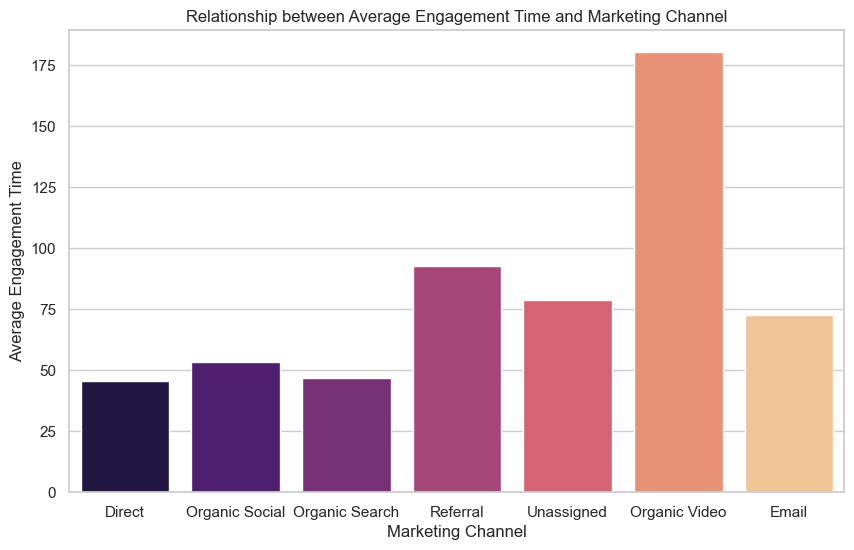

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Channel Group', y='Average engagement time per session', data=df, estimator=np.mean, palette='magma', errorbar=None)
plt.xlabel('Marketing Channel')
plt.ylabel('Average Engagement Time')
plt.title('Relationship between Average Engagement Time and Marketing Channel')
plt.show()


In [62]:
df.groupby('Channel Group')['Average engagement time per session'].mean().round(2).sort_values(ascending=False)

Channel Group
Organic Video     180.36
Referral           92.66
Unassigned         78.96
Email              72.67
Organic Social     53.49
Organic Search     47.01
Direct             45.53
Name: Average engagement time per session, dtype: float64

`Organic Video` has the highest average engagement time per session at 180.36 seconds, followed by `Referral` at 92.66 seconds. One interesting thing to note is that even though `Organic Video` and `Email` invites low users, they have relatively high engagement times. This could be due to the fact that users who are invited through organic video and email are more likely to be interested in the content and are more likely to engage with it. Hence, if the team want to increase the engagement time per session, they should focus on organic video and email.

---

### How does engagement rate vary with different traffic channels?


Creating a boxplot to compare the engagement rate distribution of different traffic channels

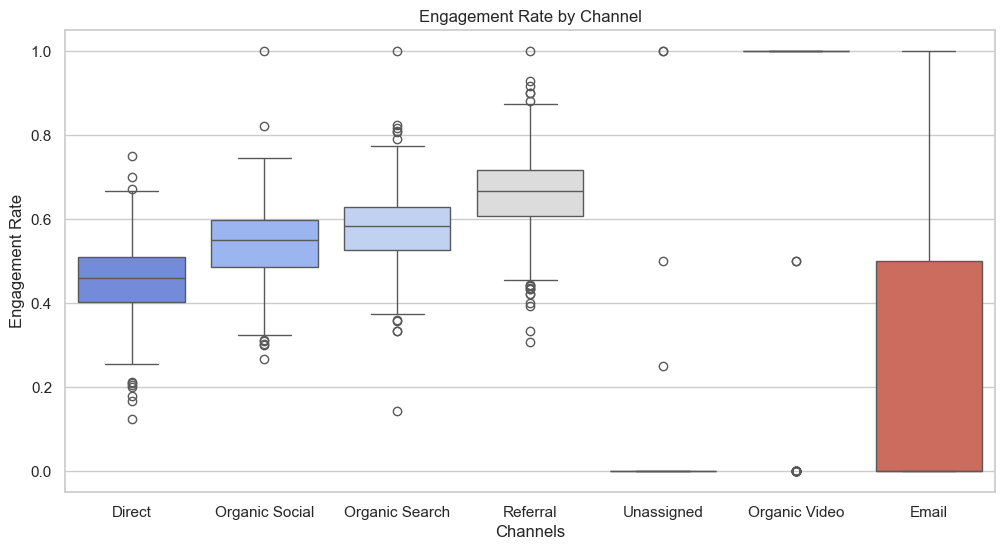

In [67]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Channel Group', y='Engagement rate', data=df, palette='coolwarm')
plt.title('Engagement Rate by Channel')
plt.xlabel('Channels')
plt.ylabel('Engagement Rate')
plt.show()

`Referral` channel has the highest engagement rate, followed by `Organic Search` and `Organic Social`.

---
### What channels are driving more engaged sessions comapred to non-engaged sessions?

Creating a column `'Non-Engaged'` by subtracting 'Engaged Sessions' from Total sessions. Then, I created a barplot to compare the number of engaged and non-engaged sessions for each channel.

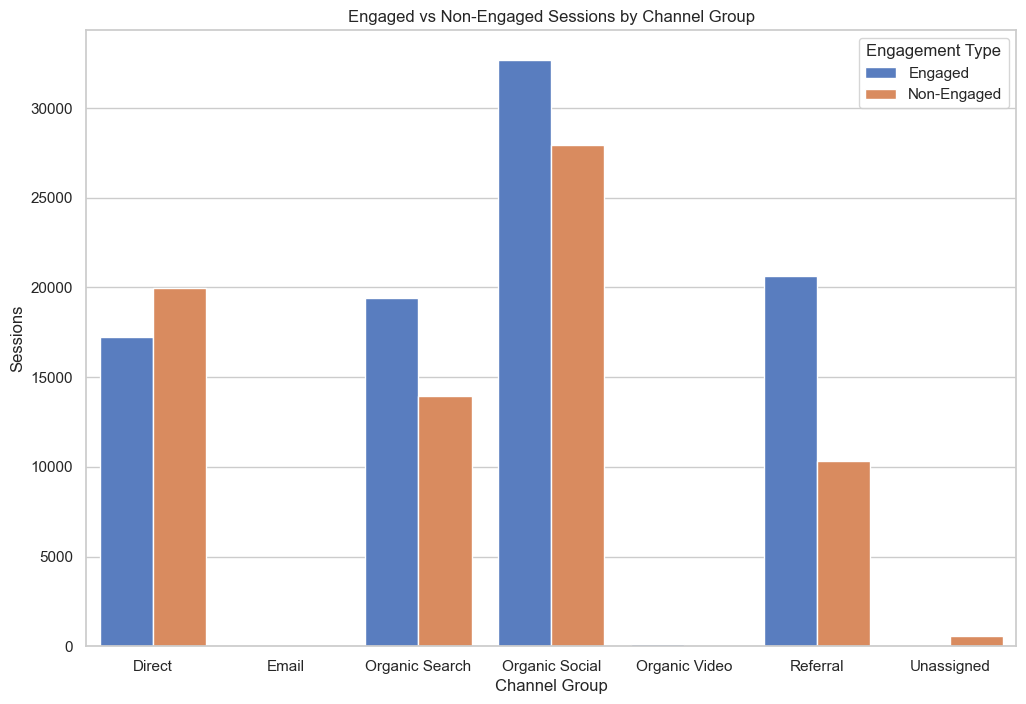

In [82]:
session_df = df.groupby('Channel Group')[['Engaged sessions', 'Sessions']].sum().reset_index()
session_df['Non-Engaged'] = session_df['Sessions'] - session_df['Engaged sessions']
session_df_melted = session_df.melt(id_vars='Channel Group', value_vars=['Engaged sessions', 'Non-Engaged'])
session_df_melted['Engagement Type'] = session_df_melted['variable'].replace({'Engaged sessions': 'Engaged', 'Non-Engaged': 'Non-Engaged'})

plt.figure(figsize=(12, 8))
sns.barplot(x='Channel Group', y='value', hue='Engagement Type', data=session_df_melted, palette='muted')
plt.xlabel('Channel Group')
plt.ylabel('Sessions')
plt.title('Engaged vs Non-Engaged Sessions by Channel Group')
plt.show()

`Orgnanic Social` has very high number of engaged and non-engaged sessions, and the engaged sessions are greater than the non-engaged sessions, which means that the organic social channel is performing well in terms of engagement. Similarly, `Organic Search` and `Referral` channels have higher number of engaged sessions than non-engaged sessions. However, `Direct` channel has lower number of engaged sessions than non-engaged sessions, which means that the direct channel is performing poorly in terms of engagement. Hence, the company should focus on improving the performance of the direct channel.

---
### What hours of the day are the most active for website traffic?

Creating a heatmap to visualize the website traffic by hour of the day.

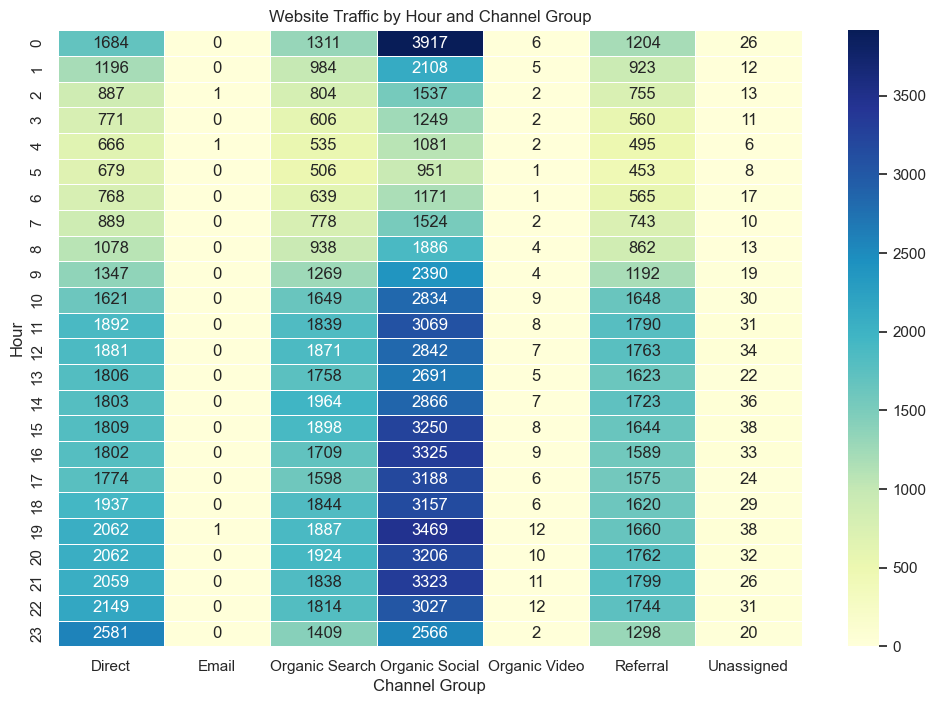

In [85]:
heatmap_data = df.groupby(['Hour', 'Channel Group'])['Sessions'].sum().unstack()
heatmap_data = heatmap_data.fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Website Traffic by Hour and Channel Group')
plt.xlabel('Channel Group')
plt.ylabel('Hour')
plt.show()

`Organic Social` has the highest traffic with 3917 sessions at 12:00 midnight and it also has a consistenly high traffic of 2500+ sessions from 10:00 to 22:00. `Referral` has the highest traffic with 1799 sessions at 21:00 and it also has a consistenly high traffic of 1500-1800 sessions from 10:00 to 22:00. Similar conclusion can be drawn from `Organic Search` with 1600+ sessions and `Direct` with 1800-2100 sessions during the same time period. 

----
### Is there any correlation between the traffic sessions and engagement rate over time?

Creating an overlaid line chart to show the traffic sessions and engagement rate over time.

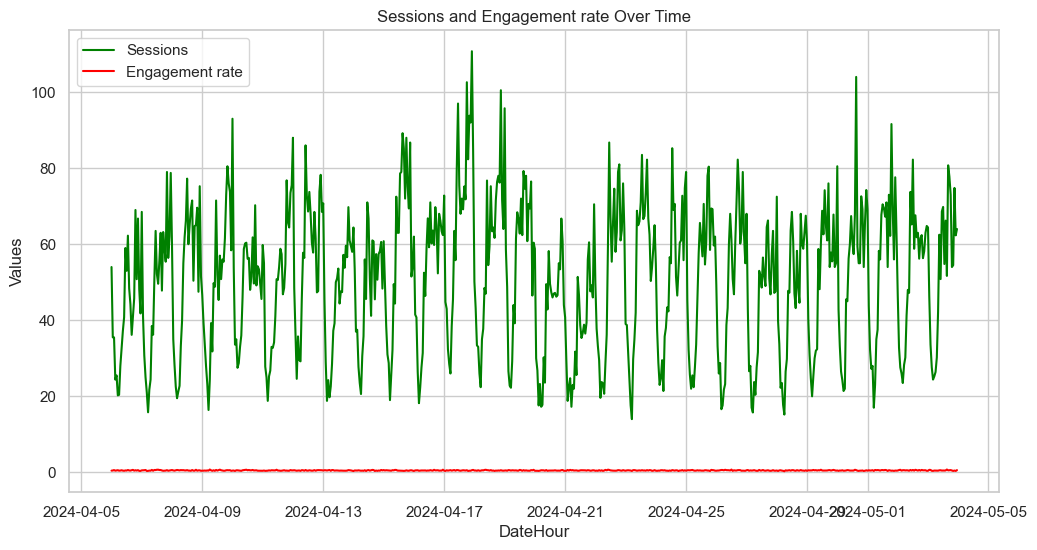

In [90]:
df_plot = df.groupby(['DateHour'])[['Sessions', 'Engagement rate']].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_plot['DateHour'], df_plot['Sessions'], label='Sessions', color='green')
plt.plot(df_plot['DateHour'], df_plot['Engagement rate'], label='Engagement rate', color='red')
plt.xlabel('DateHour')
plt.ylabel('Values')
plt.title('Sessions and Engagement rate Over Time')
plt.legend()
plt.show()

The graph shows that from April 5 2024 to May 5 2024, there is a great flactuation in the number of sessions, but the engagement rate is relatively low compared to the number of sessions.

Standardizing the Sessions and Engagement rate columns

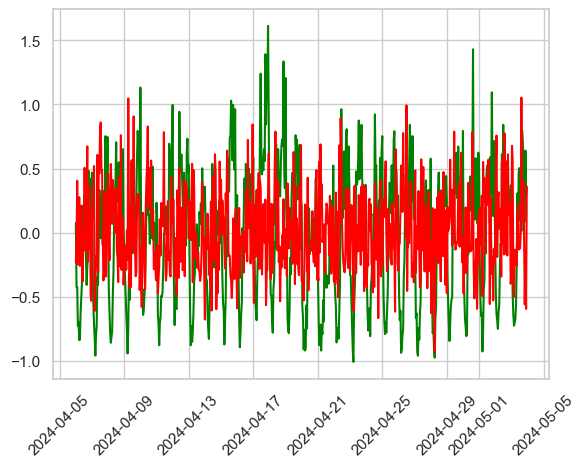

In [94]:
df_standardized = df.copy()
df_standardized['Sessions'] = (df_standardized['Sessions'] - df_standardized['Sessions'].mean()) / df_standardized['Sessions'].std()
df_standardized['Engagement rate'] = (df_standardized['Engagement rate'] - df_standardized['Engagement rate'].mean()) / df_standardized['Engagement rate'].std()

df_standardized_plot = df_standardized.groupby(['DateHour'])[['Sessions', 'Engagement rate']].mean().reset_index()

plt.plot(df_standardized_plot['DateHour'], df_standardized_plot['Sessions'], label='Sessions', color='green')
plt.plot(df_standardized_plot['DateHour'], df_standardized_plot['Engagement rate'], label='Engagement rate', color='red')
plt.xticks(rotation=45)
plt.show()


After standardizing the data, the graph shows that from April 5 2024 to May 5 2024, there is a great flactuation in the number of sessions and the engagement rate.

Calculate the correlation between the number of sessions and the engagement rate.

In [95]:
df[['Sessions', 'Engagement rate']].corr()

,Sessions,Engagement rate
Sessions,1.000000,0.303394
Engagement rate,0.303394,1.000000


There is a weak positive correlation of 0.303 between the number of sessions and the engagement rate. This means that as the number of sessions increases, the engagement rate also increases, but not by a large margin.

---

## Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)